## **Project Report: Naive Bayes Classifier**



# Introduction

**Project 1** - The SMS Spam Collection dataset is used to build and evaluate a Naive Bayes Classifier for detecting unwanted or promotional messages. It is a binary classification problem where each SMS message is labeled as either spam or ham (not spam). The task involves learning the distinguishing word patterns that frequently appear in spam messages—such as “free,” “win,” or “prize”—to automatically identify new spam texts. Since SMS messages are typically short and concise, a Binary ON/OFF Naive Bayes model is employed, where the presence or absence of specific keywords provides stronger predictive power than their frequency.

**Project 2** - The BBC News Summary dataset serves as the basis for a multi-class text classification problem, categorizing news articles into five topics: business, entertainment, politics, sport, and technology. Each article's word distribution is analyzed to learn class-specific vocabulary and identify the most indicative words for each category. Because news documents are longer and word frequency carries more meaning, a Multinomial Naive Bayes model is implemented. Together, these two datasets demonstrate the versatility of the Naive Bayes algorithm for different types of textual data, showcasing its simplicity, scalability, and effectiveness in natural language processing tasks.

# SMS Spam Collection

**Data Loading and Preprocessing**

In the following upcoming steps:
1. All letters are converted to lowercase
2. Useless words(like articles, pronouns, etc.) & punctuations in sentences are removed.
3. The resultant text are tokenized

Importing libraries & Modules


In [ ]:
import pandas as pd
import string
import re
from collections import Counter
from collections import defaultdict
import math
from google.colab import files
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import zipfile
import os
import urllib.request

In [ ]:
def preprocess(text):

    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r'\d+', '', text)
    text = text.strip()
    stop_words = {
        "a", "an", "the",
        "i", "me", "my", "mine", "myself",
        "we", "us", "our", "ours", "ourselves",
        "you", "your", "yours", "yourself", "yourselves",
        "he", "him", "his", "himself",
        "she", "her", "hers", "herself",
        "it", "its", "itself",
        "they", "them", "their", "theirs", "themselves",
        "ltgt", "gt", "lt"
    }
    tokens = text.split()
    tokens = [word for word in tokens if word.isascii() and word.isalpha() and word not in stop_words]
    tokens = [word for word in tokens if len(word) > 1]

    return tokens


Download the dataset

In [ ]:

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip"
zip_file_path = "smsspamcollection.zip"
urllib.request.urlretrieve(url, zip_file_path)


with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall()


df_sms= pd.read_csv("SMSSpamCollection", sep="\t", names=["label", "tokens"])

print(df_sms.head())

  label                                             tokens
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [ ]:
df_sms['tokens'] = df_sms['tokens'].apply(preprocess)
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df_sms['tokens'], df_sms['label'], test_size=0.2, random_state=42
)

Building Vocabulary From Training Data

In [ ]:
def build_vocabulary(tokens_list):
    vocabulary = Counter()
    for tokens in tokens_list:
        vocabulary.update(tokens)
    return set(vocabulary.keys())

vocab = build_vocabulary(train_texts)
print("Vocabulary size:", len(vocab))


Vocabulary size: 7526


**Naive Bayes Implementation**

Computations of Priors

In [ ]:
def compute_prior(labels):

    priors = defaultdict(float)
    total = len(labels)


    for label in labels:
        priors[label] += 1


    for c in priors:
        priors[c] /= total

    return dict(priors)

priors = compute_prior(train_labels)
print("Priors:", priors)
# spam: 598,ham=3859

Priors: {'spam': 0.13417096701817366, 'ham': 0.8658290329818263}


Compute the likelihood

In [ ]:
def compute_likelihoods(texts, labels, vocab, alpha=1.0, binary=False):

    word_counts = {c: Counter() for c in set(labels)}
    class_counts = Counter(labels)


    for tokens, label in zip(texts, labels):
        if binary:
            tokens = set(tokens)
        word_counts[label].update(tokens)


    likelihoods = {}
    for c in word_counts:
        total_words = sum(word_counts[c].values()) if not binary else class_counts[c]
        likelihoods[c] = {}
        for w in vocab:
            likelihoods[c][w] = (word_counts[c][w] + alpha) / (total_words + alpha * len(vocab))

    return likelihoods

likelihoods = compute_likelihoods(train_texts, train_labels, vocab, alpha=1.0, binary=True)


Compute Log Posterior

In [ ]:

def compute_log_posterior(tokens, priors, likelihoods, vocab, binary=False):
    scores = {}
    if binary:
        tokens = set(tokens)

    for c in priors:
        log_prob = math.log(priors[c])
        for w in tokens:
            if w in vocab:
                log_prob += math.log(likelihoods[c][w])
        scores[c] = log_prob

    return scores


Prediction

In [ ]:
def predict(tokens, priors, likelihoods, vocab, binary=True):
    scores = compute_log_posterior(tokens, priors, likelihoods, vocab, binary)
    return max(scores, key=scores.get)

preds = [predict(t, priors, likelihoods, vocab, binary=True) for t in test_texts]

Compute Accuracy

In [ ]:
def compute_accuracy(preds, labels):
    correct = sum(p == l for p, l in zip(preds, labels))
    return correct / len(labels)

accuracy = compute_accuracy(preds, test_labels)
print(f"Test Accuracy: {accuracy:.4f}")


Test Accuracy: 0.9650


Example test cases for SMS Spam

In [ ]:
exp_test_case = [
    "Win free tickets now!!!",
    "Are you coming to the meeting?",
    "URGENT! You won $1000",
    "See you tomorrow at lunch"
]
exp_labels = ["spam", "ham", "spam", "ham"]

exp_preds = [predict(preprocess(t), priors, likelihoods, vocab, binary=True) for t in exp_test_case]

print("Predicted Labels:", exp_preds)

exp_acc = compute_accuracy(exp_preds, exp_labels)
print(f"Example Test Cases Accuracy: {exp_acc:.2f}")


Predicted Labels: ['spam', 'ham', 'spam', 'ham']
Example Test Cases Accuracy: 1.00


**Confusion Matrix:**
A Confusion Matrix is a powerful tool in classification problems that allows to evaluate the performance of a model by comparing the predicted labels with the actual labels. It provides a detailed breakdown of the model's performance, highlighting its strengths and weaknesses in terms of correct and incorrect classifications.

Confusion Matrix :
             Predicted Ham  Predicted Spam
Actual Ham             966               0
Actual Spam             39             110


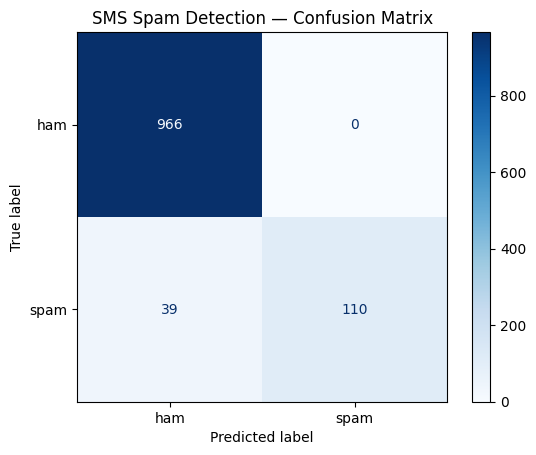

In [ ]:
cm = confusion_matrix(test_labels, preds, labels=["ham", "spam"])


cm_df = pd.DataFrame(cm, index=["Actual Ham", "Actual Spam"], columns=["Predicted Ham", "Predicted Spam"])


print("Confusion Matrix :")
print(cm_df)


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["ham", "spam"])


disp.plot(cmap='Blues', values_format='d')

plt.title("SMS Spam Detection — Confusion Matrix")


plt.show()

Top Indicative Words

In [ ]:
def top_indicative_words(likelihoods, class1, class2, top_n=10):
    ratios = {}
    for w in likelihoods[class1]:
        ratio = math.log(likelihoods[class1][w] / likelihoods[class2][w])
        ratios[w] = ratio
    return sorted(ratios.items(), key=lambda x: x[1], reverse=True)[:top_n]

print("Top indicative words for SPAM:")
print(top_indicative_words(likelihoods, "spam", "ham", 10))

print("Top indicative words for HAM:")
print(top_indicative_words(likelihoods, "ham", "spam", 10))


Top indicative words for SPAM:
[('claim', 4.768290854640878), ('prize', 4.415011499703284), ('won', 4.307765969349687), ('guaranteed', 4.051046122501872), ('ppm', 3.892822117286978), ('tone', 3.863834580413726), ('awarded', 3.833981617264045), ('tcs', 3.5955705938190468), ('pobox', 3.4729682717267143), ('weekly', 3.4729682717267143)]
Top indicative words for HAM:
[('lor', 4.389913762914776), ('later', 4.37205614551477), ('ill', 4.226874135670271), ('oh', 4.105177200692752), ('thats', 3.9800140577387455), ('doing', 3.9391920632184907), ('already', 3.8672185635934015), ('didnt', 3.805660670593968), ('ask', 3.7733998083757463), ('said', 3.7733998083757463)]


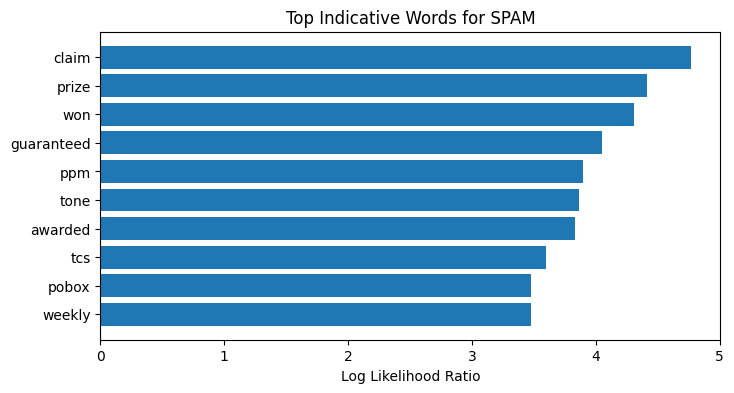

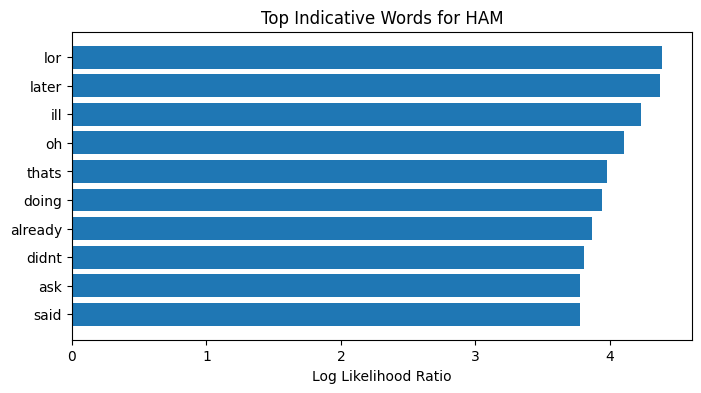

In [ ]:
def plot_top_words(top_words, title):
    words, scores = zip(*top_words)
    plt.figure(figsize=(8, 4))
    plt.barh(words, scores)
    plt.xlabel("Log Likelihood Ratio")
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.show()

plot_top_words(top_indicative_words(likelihoods, "spam", "ham", 10), "Top Indicative Words for SPAM")
print('\n\n')
plot_top_words(top_indicative_words(likelihoods, "ham", "spam", 10), "Top Indicative Words for HAM")


**Analysis:**

For the SMS Spam Collection dataset, the Binary ON/OFF Naive Bayes model performed effectively in distinguishing between spam and ham messages. The classifier achieved high accuracy by leveraging the presence of strong indicator words such as “free”, “win”, “urgent”, and “prize”, which frequently occur in spam messages. In contrast, ham messages contained more conversational and neutral words like “meeting”, “see”, or “tomorrow”. The binary model proved well-suited for short text messages, where the mere presence of a word is more informative than its frequency. The confusion matrix showed that most messages were correctly classified, with very few false positives, indicating that the model generalized well on unseen data.

# BBC News Articles

In [ ]:
!pip install kagglehub

In [ ]:
import pandas as pd
import requests
import zipfile
import io
import kagglehub
import re
from sklearn.model_selection import train_test_split
import os

In [ ]:
path = kagglehub.dataset_download("pariza/bbc-news-summary")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'bbc-news-summary' dataset.
Path to dataset files: /kaggle/input/bbc-news-summary


In [ ]:
base_path = os.path.join(path,'bbc news summary/BBC News Summary/News Articles')
print(os.listdir(base_path))

['politics', 'sport', 'tech', 'entertainment', 'business']


**Data Loading and Preprocessing**

In the following upcoming steps:
1. All letters are converted to lowercase
2. Useless words(like articles, pronouns, etc.) & punctuations in sentences are removed.
3. The resultant text are tokenized

In [ ]:
def preprocess(text):
    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r'\d+', '', text)
    text = text.strip()
    stop_words = {
        "a", "an", "the",
        "i", "me", "my", "mine", "myself",
        "we", "us", "our", "ours", "ourselves",
        "you", "your", "yours", "yourself", "yourselves",
        "he", "him", "his", "himself",
        "she", "her", "hers", "herself",
        "it", "its", "itself",
        "they", "them", "their", "theirs", "themselves",
        "ltgt", "gt", "lt"
    }

    tokens = text.split()


    tokens = [word for word in tokens if word.isascii() and word.isalpha() and word not in stop_words]

    tokens = [word for word in tokens if len(word) > 1]

    return tokens


In [ ]:
data = []
for label in os.listdir(base_path):
  print(f'Class {label} adding...')
  folder = os.path.join(base_path,label)
  for txt_file in os.listdir(folder):
    with open(os.path.join(folder,txt_file),'r', encoding='latin1') as f:
      text = f.read().lower()
      data.append((text,label))
  print(f'{label} class successfully added')

df = pd.DataFrame(data,columns=['Text', 'Label'])
train_df, test_df = train_test_split(df,test_size=0.2, random_state=42)
print('\n')
print(f'Train Size = {train_df.shape}')
print(f'Test Size = {test_df.shape}')
print('Dataset Snapshot: ')
print(df.head())

Class politics adding...
politics class successfully added
Class sport adding...
sport class successfully added
Class tech adding...
tech class successfully added
Class entertainment adding...
entertainment class successfully added
Class business adding...
business class successfully added


Train Size = (1780, 2)
Test Size = (445, 2)
Dataset Snapshot: 
                                                Text     Label
0  budget to set scene for election\n\ngordon bro...  politics
1  army chiefs in regiments decision\n\nmilitary ...  politics
2  howard denies split over id cards\n\nmichael h...  politics
3  observers to monitor uk election\n\nministers ...  politics
4  kilroy names election seat target\n\nex-chat s...  politics


In [ ]:
from collections import defaultdict, Counter
def tokenize(text):
  return text.split()
vocab = set()

for text in train_df['Text']:
  vocab.update(tokenize(text))
vocab = list(vocab)
print("Vocabulary Size: ", end = "")
print(len(vocab))

Vocabulary Size: 53483


**Naive Bayes Implementation**

Priori Probability P(C)

In [ ]:
import numpy as np
classes = train_df['Label'].unique()

priors={}
for c in classes:
  priors[c]= len(train_df[train_df['Label']==c])/len(train_df)
print(priors)

{'entertainment': 0.17415730337078653, 'business': 0.2292134831460674, 'sport': 0.23202247191011235, 'politics': 0.18258426966292135, 'tech': 0.18202247191011237}


Likelihood Estimation

In [ ]:
alpha = 1
class_word_totals={}
word_counts = {c:Counter() for c in classes}



for i, row in train_df.iterrows():
      words = tokenize(row["Text"])
      word_counts[row["Label"]].update(words)

for c in classes:
    class_word_totals[c]=sum(word_counts[c].values())


P_wc = {}

for c in classes:
    P_wc[c]={}
    for w in vocab:
      P_wc[c][w] = (word_counts[c][w] + alpha)/(class_word_totals[c]+ alpha * len(vocab))



Prediction

In [ ]:
def predict(text):
   words = tokenize(text)
   scores = {}
   for c in classes:
     score = np.log(priors[c])
     for w in words:
       if w in vocab:
         score += np.log(P_wc[c][w])
     scores[c] = score
   return max(scores, key = scores.get)


Accuracy & Confusion Matrix

BBC Test Accuracy: 0.9640


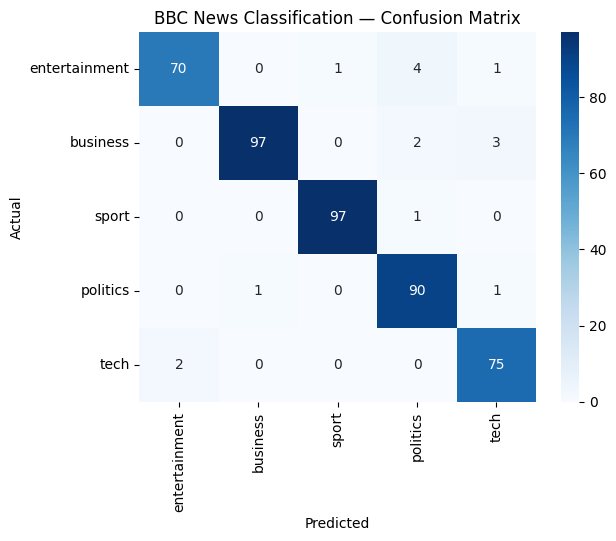


Some Misclassified Examples:
Actual: entertainment, Predicted: politics, Text: brookside creator's channel 4 bid

the creator of defunct tv soap brookside has written to the cultu...


In [ ]:
y_true, y_pred = [], []

# Predict on test data
for i, row in test_df.iterrows():
    y_true.append(row["Label"])
    y_pred.append(predict(row['Text']))

from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


acc = accuracy_score(y_true, y_pred)
print(f"BBC Test Accuracy: {acc:.4f}")


cm = confusion_matrix(y_true, y_pred, labels=classes)
sns.heatmap(cm, annot=True, xticklabels=classes, yticklabels=classes, cmap="Blues", fmt="d")
plt.title("BBC News Classification — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\nSome Misclassified Examples:")
for i, (true, pred) in enumerate(zip(y_true, y_pred)):
    if true != pred and i < 5:
        print(f"Actual: {true}, Predicted: {pred}, Text: {test_df.iloc[i]['Text'][:100]}...")

Some BBC News articles were misclassified due to overlapping vocabulary between topics.

For example, the article “Brookside creator's Channel 4 bid” was labeled entertainment but predicted as politics, likely because terms like “Channel 4” and “culture” frequently appear in political or media-policy news articles.

In [ ]:
from math import log

indicative_words = {}
for c in classes:
    word_scores = {}
    for w in vocab:
        p_wc = P_wc[c][w]
        p_w = sum(P_wc[cc][w] * priors[cc] for cc in classes)
        word_scores[w] = log(p_wc / p_w)
    indicative_words[c] = sorted(word_scores, key=word_scores.get, reverse=True)[:10]

for c in classes:
    print(f"\nTop indicative words for {c}:")
    print(indicative_words[c])



Top indicative words for entertainment:
['actress', 'oscar', 'actor', 'festival', 'singer', 'comedy', 'starring', 'album', 'band', 'aviator']

Top indicative words for business:
['yukos', 'oil', 'shares', 'deutsche', 'fiat', 'stock', 'bankruptcy', 'gazprom', 'economist', 'lse']

Top indicative words for sport:
['coach', 'cup', 'rugby', 'champion', 'chelsea', 'champions', 'roddick', 'athens', 'slam', 'lions']

Top indicative words for politics:
['tory', 'tories', 'lib', "labour's", 'liberal', 'dems', 'asylum', 'ukip', 'blunkett', 'blair']

Top indicative words for tech:
['users', 'microsoft', 'apple', 'broadband', 'portable', 'gadgets', 'software', 'web', 'spam', 'mobiles']


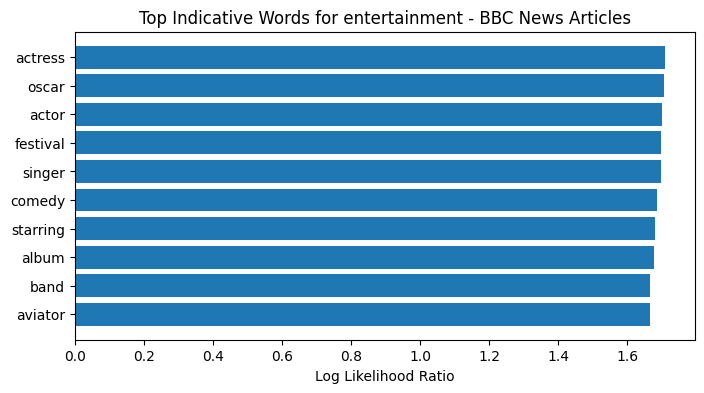

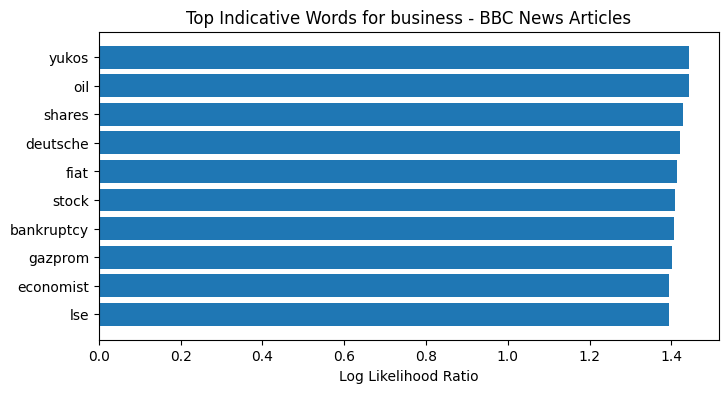

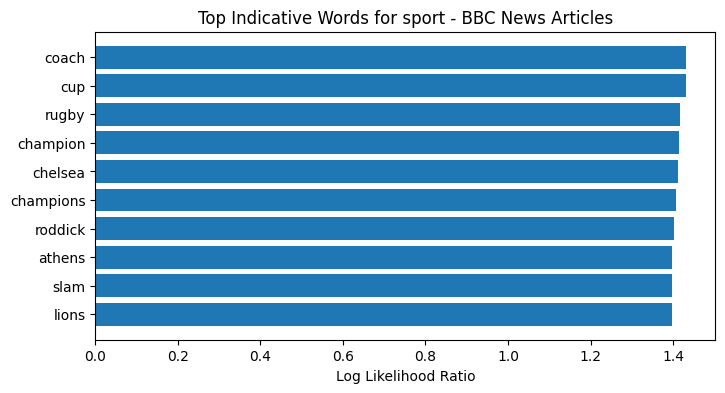

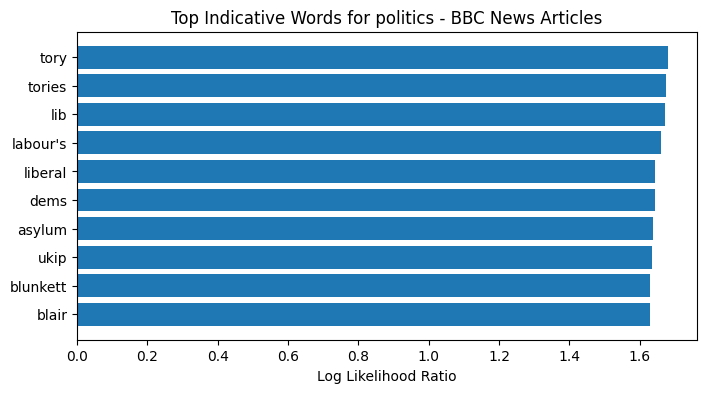

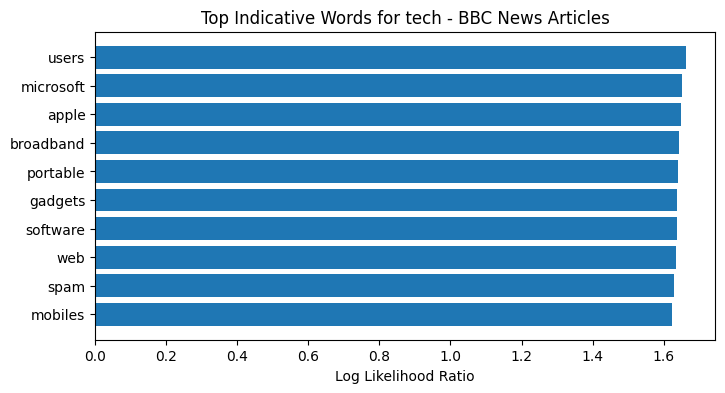

In [ ]:
def plot_bbc_top_words(indicative_words, title):
    for c, words in indicative_words.items():
        word_scores = {}
        for w in words:
            p_wc = P_wc[c][w]
            p_w = sum(P_wc[cc][w] * priors[cc] for cc in classes)
            word_scores[w] = log(p_wc / p_w)

        sorted_word_scores = sorted(word_scores.items(), key=lambda x: x[1], reverse=True)
        plot_top_words(sorted_word_scores, f"Top Indicative Words for {c} - {title}")
        print('\n\n')

plot_bbc_top_words(indicative_words, "BBC News Articles")

**Analysis:**

For the BBC News Summary dataset, the Multinomial Naive Bayes model successfully captured the differences between the five news categories—business, entertainment, politics, sport, and technology. Word frequency played a crucial role in this dataset, as repeated domain-specific terms such as “stock”, “market” (business), “film”, “music” (entertainment), “government”, “election” (politics), “match”, “team” (sport), and “software”, “device” (technology) strongly influenced classification. The model achieved strong accuracy and a well-balanced confusion matrix, demonstrating its ability to learn distinct word distributions across topics. Overall, the analysis confirmed that Naive Bayes remains an efficient and interpretable baseline for text classification, performing reliably across both short and long-form textual data.

**Conclusion:**

The SMS Spam Classification project demonstrated that the Binary ON/OFF Naive Bayes model is highly suitable for short message filtering tasks. By utilizing the presence or absence of specific indicative words, the model effectively distinguished spam messages from legitimate ones. Keywords such as “free”, “win”, and “prize” showed strong associations with spam, while neutral and conversational terms characterized ham messages. The model achieved reliable accuracy with minimal computational requirements, emphasizing the efficiency and interpretability of Naive Bayes for simple yet practical text classification problems like spam detection.



The BBC News Classification project highlighted the capability of the Multinomial Naive Bayes model in handling multi-class text classification tasks involving longer documents. The model successfully learned and differentiated between domain-specific vocabularies across various topics such as business, entertainment, politics, sports, and technology. Frequent words related to each category contributed significantly to accurate predictions, showing that word frequency plays a key role in document classification. Overall, the project reaffirmed that Naive Bayes remains a robust and computationally efficient baseline for text classification, capable of delivering strong results while maintaining model simplicity and interpretability.